In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
import json, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# stats
from scipy.stats import ttest_ind, f_oneway, kruskal

# ------------------------
# EDIT THESE
# ------------------------
CACHE_ROOT   = Path("../../outputs/aptos_cache")

RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
RUN_ID_STAGE3 = "aptos2019_stage3_cd3f6ffabc"
RUN_ID_STAGE4 = "aptos2019_stage4_7741334624"   # <-- your completed stage4 run id

STAGE1_ROOT = CACHE_ROOT / RUN_ID_STAGE1 / "stage1"
STAGE2_ROOT = CACHE_ROOT / RUN_ID_STAGE2 / "stage2"
STAGE3_ROOT = CACHE_ROOT / RUN_ID_STAGE3 / "stage3"
STAGE4_ROOT = CACHE_ROOT / RUN_ID_STAGE4 / "stage4"

assert STAGE4_ROOT.exists(), f"Missing {STAGE4_ROOT}"
print("Stage4 dir:", STAGE4_ROOT)

GROUP_ORDER = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative"]  # APTOS 2019 folders


Stage4 dir: ..\..\outputs\aptos_cache\aptos2019_stage4_7741334624\stage4


In [3]:
def list_stage4_jsons(stage4_root: Path):
    return sorted(stage4_root.glob("*/biomarkers.json"))

paths = list_stage4_jsons(STAGE4_ROOT)
print("stage4 json count:", len(paths))

outs = []
for p in tqdm(paths):
    try:
        outs.append(json.loads(p.read_text()))
    except Exception as e:
        print("[warn] failed reading", p, e)

print("loaded outs:", len(outs))

def get_group(image_id: str) -> str:
    # image_id is like "Severe/img130"
    return (image_id.split("/")[0] if "/" in image_id else "UNKNOWN")

# group them
outs_by_group = {g: [] for g in GROUP_ORDER}
outs_by_group["UNKNOWN"] = []

for o in outs:
    g = get_group(o.get("image_id",""))
    outs_by_group.setdefault(g, []).append(o)

for g in GROUP_ORDER:
    print(g, len(outs_by_group.get(g, [])))
if outs_by_group["UNKNOWN"]:
    print("UNKNOWN:", len(outs_by_group["UNKNOWN"]))


stage4 json count: 3665


100%|██████████| 3665/3665 [01:13<00:00, 50.09it/s]

loaded outs: 3665
No_DR 1808
Mild 370
Moderate 999
Severe 193
Proliferative 295


In [4]:
def flatten_metrics_stage4(o, um_per_px=None):
    """
    Flattens Stage4 'biomarkers.json' into one row:
      - global: FD, density%, tort, caliber
      - rings:  0.5-1.0,1.0-1.5,1.5-2.0,2.0-2.5 (if present)
      - quadrants: I,S,N,T for same 4 metrics (if present)
    """
    bio = o.get("biomarkers") or {}
    g   = bio.get("global") or {}
    rings = bio.get("rings") or {}
    quads = bio.get("quadrants") or {}

    row = {}

    # ---- GLOBAL ----
    row["fractal_dimension"] = float(g.get("fractal_dimension", np.nan))
    row["area_density_pct"]  = 100.0 * float(g.get("area_density", np.nan))
    row["tortuosity_px2"]    = float(g.get("tortuosity_mean", np.nan))

    vco = g.get("vc_orth") or {}
    med_w_px = float(vco.get("median_width", np.nan))
    iqr_w_px = float(vco.get("iqr_width",   np.nan))
    if um_per_px is not None and np.isfinite(med_w_px):
        row["caliber_um"] = med_w_px * um_per_px
    else:
        row["caliber_px"] = med_w_px
    row["median_width_px"] = med_w_px
    row["iqr_width_px"]    = iqr_w_px

    # ---- RINGS ----
    # keep same ring starts as your plots (0.5, 1.0, 1.5, 2.0)
    wanted_starts = [0.5, 1.0, 1.5, 2.0]
    for k, r in rings.items():
        try:
            r0 = float(str(k).split("-")[0])
        except:
            continue
        if r0 not in wanted_starts:
            continue

        row[f"{k}|fractal_dimension"] = float(r.get("fractal_dimension", np.nan))
        row[f"{k}|area_density_pct"]  = 100.0 * float(r.get("area_density", np.nan))
        row[f"{k}|tortuosity_px2"]    = float(r.get("tortuosity_mean", np.nan))

        r_med = float(r.get("median_width", np.nan))
        row[f"{k}|caliber"] = (r_med * um_per_px) if (um_per_px is not None and np.isfinite(r_med)) else r_med
        row[f"{k}|caliber_unit"] = "µm" if um_per_px is not None else "px"

    # ---- QUADRANTS (ISNT) ----
    for Q in ["I","S","N","T"]:
        q = quads.get(Q) or {}
        qg = q.get("global") or {}
        qvco = qg.get("vc_orth") or {}

        row[f"{Q}|fractal_dimension"] = float(qg.get("fractal_dimension", np.nan))
        row[f"{Q}|area_density_pct"]  = 100.0 * float(qg.get("area_density", np.nan))
        row[f"{Q}|tortuosity_px2"]    = float(qg.get("tortuosity_mean", np.nan))

        q_med = float(qvco.get("median_width", np.nan))
        row[f"{Q}|caliber"] = (q_med * um_per_px) if (um_per_px is not None and np.isfinite(q_med)) else q_med

    return row


# Build per-group DataFrames
dfs = {}
for g in GROUP_ORDER:
    arr = [flatten_metrics_stage4(o, um_per_px=None) for o in outs_by_group.get(g, [])]
    dfs[g] = pd.DataFrame(arr)
    print(g, dfs[g].shape)


No_DR (1808, 42)
Mild (370, 42)
Moderate (999, 42)
Severe (193, 42)
Proliferative (295, 42)


In [ ]:
def make_summary_table_multi(dfs_by_group: dict, *, um_scale_available=True):
    # decide caliber key
    any_df = next(iter(dfs_by_group.values()))
    cal_key = "caliber_um" if (um_scale_available and "caliber_um" in any_df.columns) else "caliber_px"
    cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

    rows = [
        ("Vascular fractal dimension",   "fractal_dimension"),
        ("Vascular density (%)",         "area_density_pct"),
        ("Vascular tortuosity (px⁻²)",   "tortuosity_px2"),
        (cal_label,                      cal_key),
    ]

    def _fmt(m, s):
        return "—" if (not np.isfinite(m)) else f"{m:.3f} ± {s:.3f}"

    out_rows = []
    for label, key in rows:
        row = {"Retinal vascular parameters": label}
        for g, df in dfs_by_group.items():
            m = float(df[key].mean(skipna=True)) if key in df.columns else np.nan
            s = float(df[key].std(skipna=True))  if key in df.columns else np.nan
            row[g] = _fmt(m, s)
        out_rows.append(row)

    return pd.DataFrame(out_rows)

tbl = make_summary_table_multi({g: dfs[g] for g in GROUP_ORDER})
tbl


,Retinal vascular parameters,No_DR,Mild,Moderate,Severe,Proliferative
0,Vascular fractal dimension,1.403 ± 0.064,1.387 ± 0.060,1.379 ± 0.058,1.348 ± 0.070,1.329 ± 0.080
1,Vascular density (%),7.169 ± 1.916,6.550 ± 1.755,6.288 ± 1.641,5.395 ± 1.581,4.975 ± 1.670
2,Vascular tortuosity (px⁻²),0.179 ± 0.008,0.184 ± 0.009,0.183 ± 0.009,0.182 ± 0.010,0.183 ± 0.010
3,Vascular caliber (px),4.978 ± 0.404,4.803 ± 0.430,4.808 ± 0.391,4.728 ± 0.407,4.623 ± 0.474


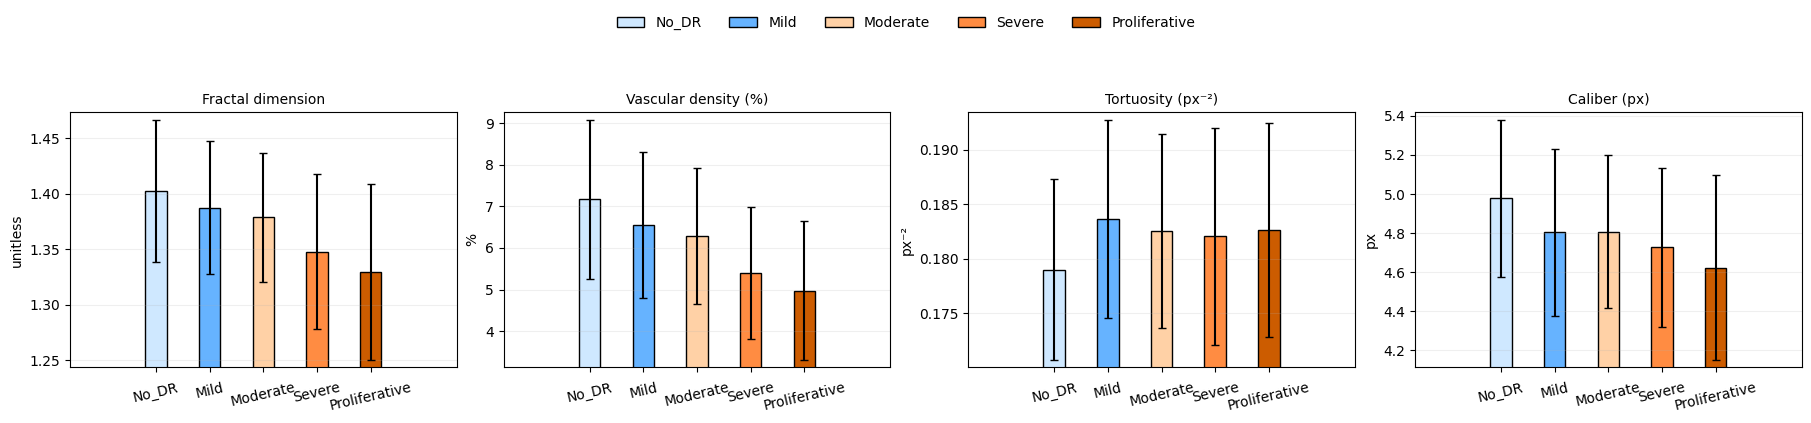

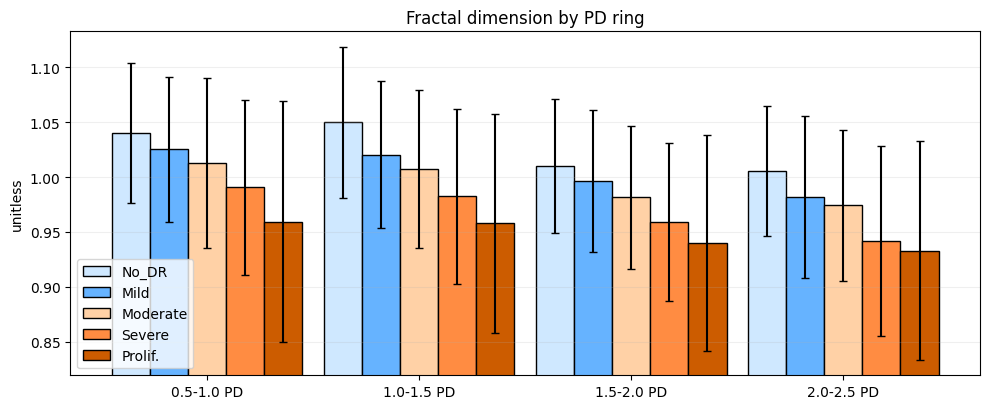

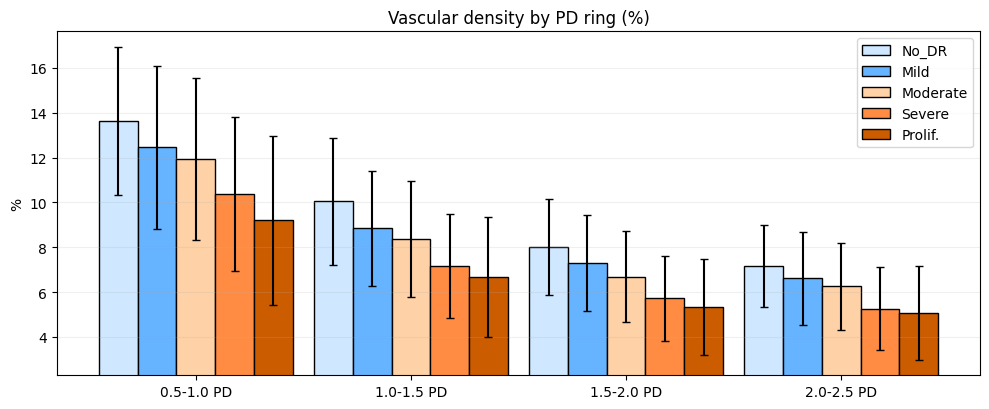

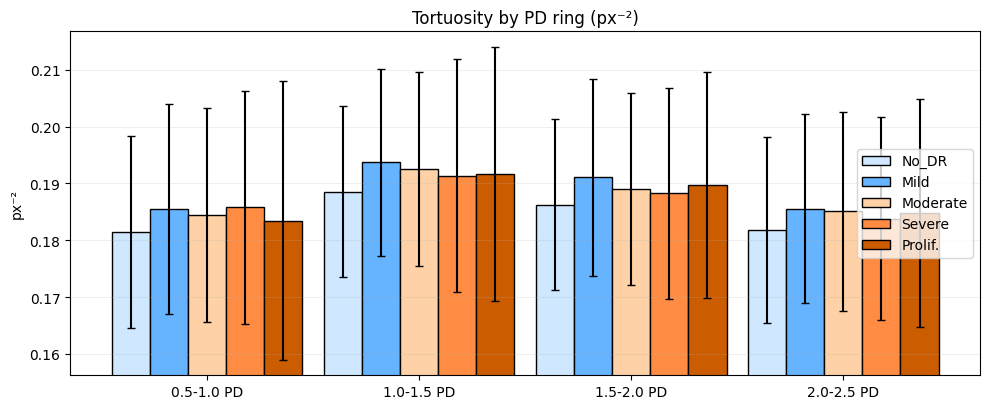

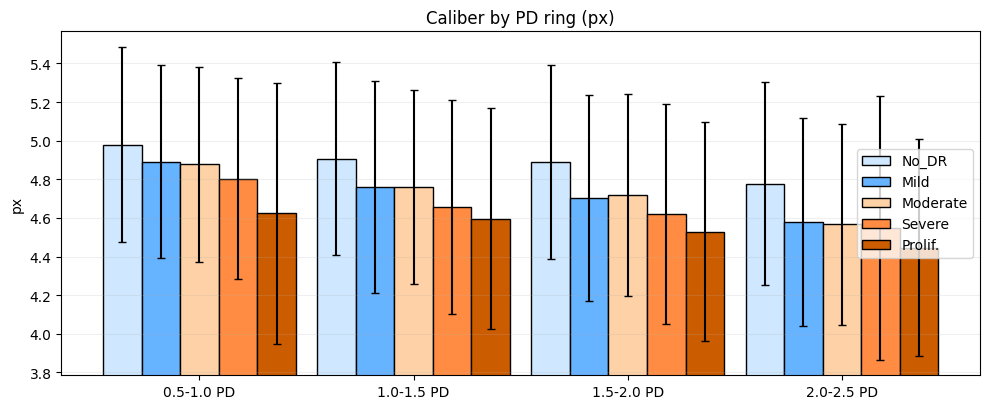

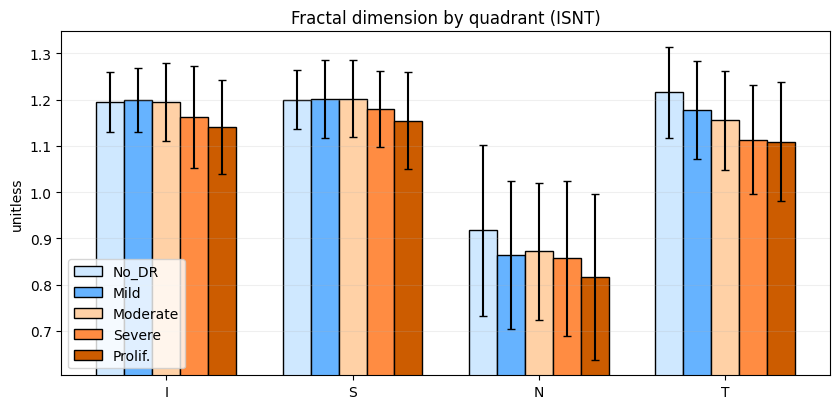

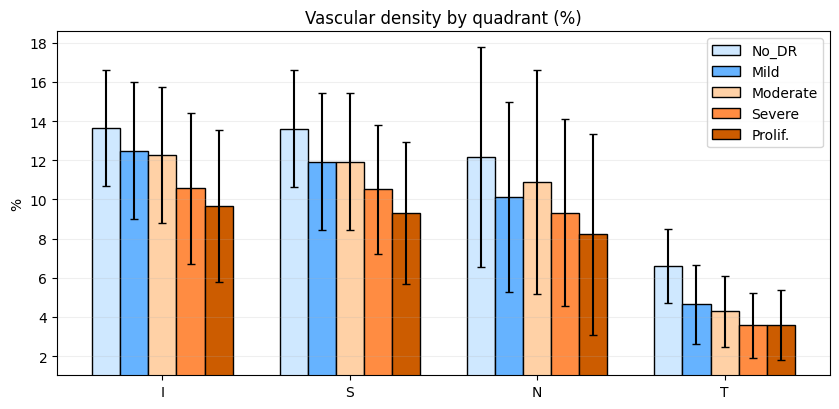

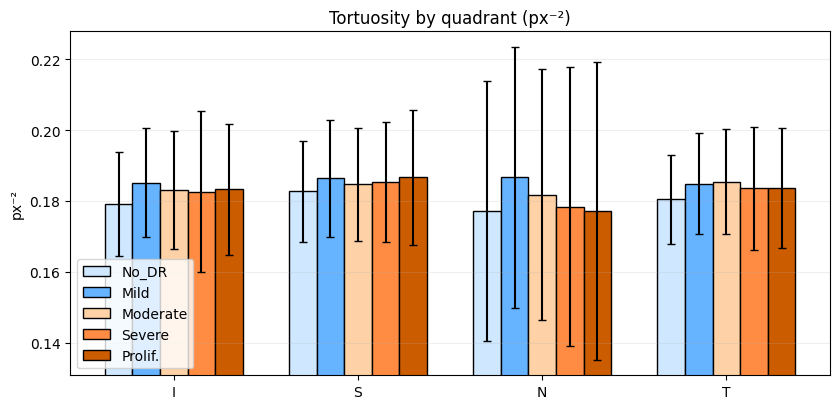

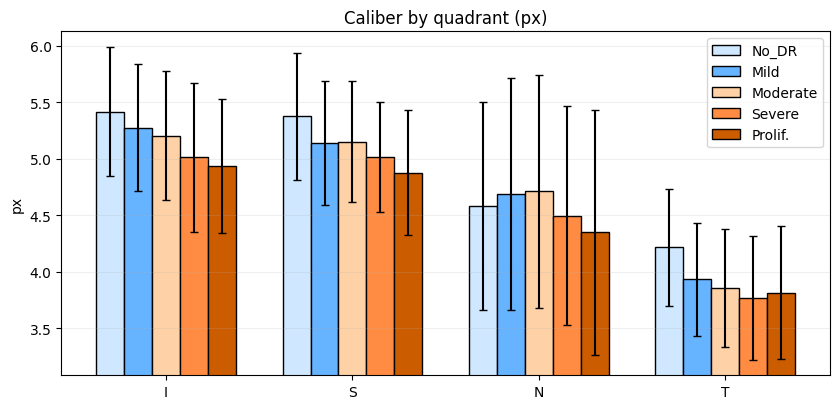

In [19]:
COLOR_MAP = {
    "No_DR": "#cfe8ff",
    "Mild": "#66b3ff",
    "Moderate": "#ffd1a6",
    "Severe": "#ff8c42",
    "Proliferative": "#cc5c00",
}


def _pretty_group_label(name: str) -> str:
    # keeps your labels readable; optional
    return "Prolif." if name.lower().startswith("prolif") else name

def _resolve_color_map(groups, color_map=None, default="#999999"):
    """
    groups: list of (gname, df)
    color_map: dict {gname: "#RRGGBB"}
    """
    colors = []
    for gname, _ in groups:
        if color_map and gname in color_map:
            colors.append(color_map[gname])
        else:
            colors.append(default)
    return colors



def bar_global_panels_v4(groups, keys, titles_map, ylabels_map,
                         figsize=(18, 5), bar_width=0.16, sep=0.34,
                         ylims=None, ypad_frac=0.03,
                         legend_top=True, legend_ncols=5, top_pad_frac=0.18,
                         color_map=None, edge_lw=1.0,
                         tick_rotation=12, tick_pad=6):
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import OrderedDict

    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1: axes = [axes]

    try:
        h_in = figsize[1]
        fig.set_constrained_layout_pads(wspace=0.02, hspace=0.02, h_pad=h_in * top_pad_frac)
    except Exception:
        fig.subplots_adjust(top=1.0 - top_pad_frac, wspace=0.02)

    G = len(groups)
    xs = np.linspace(-(G-1)/2.0, (G-1)/2.0, G) * sep

    # <-- USE YOUR HEX COLORS PER GROUP
    colors = _resolve_color_map(groups, color_map=COLOR_MAP, default="#BBBBBB")

    legend_items = OrderedDict()

    for ax, key in zip(axes, keys):
        means, sds = [], []
        for gname, df in groups:
            m = float(df[key].mean(skipna=True)) if key in df.columns else np.nan
            s = float(df[key].std(skipna=True))  if key in df.columns else np.nan
            means.append(m); sds.append(s)

        for idx, (x_i, (gname, _df), m, s) in enumerate(zip(xs, groups, means, sds)):
            err = None if np.isnan(s) else s
            b = ax.bar(
                x_i, m, yerr=err, capsize=3, width=bar_width, label=gname,
                color=colors[idx],
                edgecolor="black",
                linewidth=edge_lw
            )
            if gname not in legend_items:
                legend_items[gname] = b

        ax.set_xticks(xs)
        ax.set_xticklabels([g for g, _ in groups],
                           rotation=tick_rotation, ha="center")  # <-- centered
        ax.tick_params(axis="x", pad=tick_pad)

        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.grid(axis="y", alpha=0.2)
        ax.set_xlim(xs[0] - 1.6*sep, xs[-1] + 1.6*sep)

        if isinstance(ylims, dict) and key in ylims and ylims[key] is not None:
            ax.set_ylim(*ylims[key])
        else:
            lows, highs = [], []
            for m, s in zip(means, sds):
                if not np.isfinite(m): 
                    continue
                s = 0.0 if not np.isfinite(s) else s
                lows.append(m - s); highs.append(m + s)
            if lows and highs:
                lo, hi = min(lows), max(highs)
                pad = (hi - lo) * ypad_frac if hi > lo else 1.0
                ax.set_ylim(lo - pad, hi + pad)

    handles = [legend_items[name] for name in legend_items]
    labels  = list(legend_items.keys())
    if legend_top:
        fig.legend(handles, labels, loc="upper center",
                   bbox_to_anchor=(0.5, 1.0), ncol=legend_ncols, frameon=False)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=False)

    return fig, axes



def bar_rings_v4(groups, suffix, title, ylabel,
                 bar_width=0.18, group_gap=1.0, ylims=None, ypad_frac=0.05,
                 cmap_name="Greys", shade_lo=0.25, shade_hi=0.85,
                 edge_lw=1.0):
    import numpy as np, matplotlib.pyplot as plt

    def _ring_columns(df, suffix):
        cols = [c for c in df.columns if c.endswith("|"+suffix)]
        keyed=[]
        for c in cols:
            try:
                r0 = float(c.split("|")[0].split("-")[0])
                keyed.append((r0, c))
            except:
                pass
        return [c for _,c in sorted(keyed)]

    cols_all = [_ring_columns(df, suffix) for _, df in groups]
    cols = set(cols_all[0])
    for c in cols_all[1:]:
        cols = cols.intersection(c)
    cols = sorted(list(cols), key=lambda s: float(s.split("|")[0].split("-")[0]))
    if not cols:
        print(f"[warn] no common ring columns for '{suffix}'")
        return

    ring_labels = [c.split("|")[0].replace("PD"," PD") for c in cols]
    means = []; sds = []
    for _, df in groups:
        means.append(df[cols].mean(skipna=True).values)
        sds.append(df[cols].std(skipna=True).values)

    nR = len(cols)
    base = np.arange(nR).astype(float) * group_gap
    K = len(groups)
    offs = (np.arange(K) - (K - 1) / 2.0) * bar_width

    colors = _resolve_color_map(groups, color_map=COLOR_MAP, default="#BBBBBB")

    plt.figure(figsize=(max(10, 2.2*nR), 4.2))
    for k,(gname,_df) in enumerate(groups):
        plt.bar(base + offs[k], means[k], yerr=sds[k], capsize=3,
                width=bar_width, label=_pretty_group_label(gname),
                color=colors[k], edgecolor="black", linewidth=edge_lw)

    plt.xticks(base, ring_labels)
    plt.ylabel(ylabel); plt.title(title); plt.legend()
    plt.grid(axis="y", alpha=0.2)

    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lows_list  = []
        highs_list = []
        for m, s in zip(means, sds):
            m = np.asarray(m, dtype=float)
            s = np.nan_to_num(np.asarray(s, dtype=float), nan=0.0)
            lows_list.append(m - s)
            highs_list.append(m + s)
        lo = float(np.nanmin(np.concatenate(lows_list)))
        hi = float(np.nanmax(np.concatenate(highs_list)))
        pad = (hi - lo) * ypad_frac if hi > lo else 1.0
        plt.ylim(lo - pad, hi + pad)

    plt.tight_layout(); plt.show()



def bar_quadrants_v1(groups, suffix, title, ylabel,
                     bar_width=0.18, group_gap=1.2, ylims=None, ypad_frac=0.05,
                     cmap_name="Greys", shade_lo=0.25, shade_hi=0.85,
                     edge_lw=1.0):
    import numpy as np
    import matplotlib.pyplot as plt

    quads = ["I", "S", "N", "T"]
    cols  = [f"{q}|{suffix}" for q in quads]
    cols  = [c for c in cols if all(c in df.columns for _, df in groups)]
    if not cols:
        print(f"[warn] no common quadrant columns for '{suffix}'")
        return

    means, sds = [], []
    for _, df in groups:
        arr = df[cols].astype(float)
        means.append(arr.mean(skipna=True).values)
        sds.append(arr.std(skipna=True).values)

    nQ = len(cols)
    base = np.arange(nQ, dtype=float) * group_gap
    K = len(groups)
    offs = (np.arange(K) - (K - 1) / 2.0) * bar_width
    quad_labels = [c.split("|")[0] for c in cols]

    colors = _resolve_color_map(groups, color_map=COLOR_MAP, default="#BBBBBB")

    plt.figure(figsize=(max(8.5, 2.0 * nQ), 4.2))
    for k, (gname, _df) in enumerate(groups):
        y = np.asarray(means[k], dtype=float)
        e = np.nan_to_num(np.asarray(sds[k], dtype=float), nan=0.0)
        plt.bar(base + offs[k], y, yerr=e, capsize=3,
                width=bar_width, label=_pretty_group_label(gname),
                color=colors[k], edgecolor="black", linewidth=edge_lw)

    plt.xticks(base, quad_labels)
    plt.ylabel(ylabel); plt.title(title)
    plt.legend(); plt.grid(axis="y", alpha=0.2)

    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lows, highs = [], []
        for y, e in zip(means, sds):
            y = np.asarray(y, float); e = np.nan_to_num(np.asarray(e, float), nan=0.0)
            low  = (y - e)[np.isfinite(y - e)]
            high = (y + e)[np.isfinite(y + e)]
            if low.size:  lows.append(low)
            if high.size: highs.append(high)
        if lows and highs:
            lo = float(np.min(np.concatenate(lows)))
            hi = float(np.max(np.concatenate(highs)))
            pad = (hi - lo) * ypad_frac if hi > lo else 1.0
            plt.ylim(lo - pad, hi + pad)

    plt.tight_layout(); plt.show()

# -------------------------
# Build groups list
# -------------------------
groups = [(g, dfs[g]) for g in GROUP_ORDER]

# globals
cal_key = "caliber_um" if "caliber_um" in dfs[GROUP_ORDER[0]].columns else "caliber_px"
keys = ["fractal_dimension", "area_density_pct", "tortuosity_px2", cal_key]

titles_map = {
    "fractal_dimension": "Fractal dimension",
    "area_density_pct":  "Vascular density (%)",
    "tortuosity_px2":    "Tortuosity (px⁻²)",
    cal_key:             "Caliber (µm)" if cal_key == "caliber_um" else "Caliber (px)",
}
ylabels_map = {
    "fractal_dimension": "unitless",
    "area_density_pct":  "%",
    "tortuosity_px2":    "px⁻²",
    cal_key:             ("µm" if cal_key == "caliber_um" else "px"),
}

bar_global_panels_v4(
    groups=groups,
    keys=keys,
    titles_map=titles_map,
    ylabels_map=ylabels_map,
    color_map=COLOR_MAP,   
    sep=0.5,
    bar_width=0.2,
    tick_rotation=13
)



# rings
unit = "µm" if cal_key == "caliber_um" else "px"
bar_rings_v4(groups, "fractal_dimension", "Fractal dimension by PD ring", "unitless")
bar_rings_v4(groups, "area_density_pct",  "Vascular density by PD ring (%)", "%")
bar_rings_v4(groups, "tortuosity_px2",    "Tortuosity by PD ring (px⁻²)", "px⁻²")
bar_rings_v4(groups, "caliber",           f"Caliber by PD ring ({unit})", unit)

# quadrants
bar_quadrants_v1(groups, "fractal_dimension", "Fractal dimension by quadrant (ISNT)", "unitless")
bar_quadrants_v1(groups, "area_density_pct",  "Vascular density by quadrant (%)", "%")
bar_quadrants_v1(groups, "tortuosity_px2",    "Tortuosity by quadrant (px⁻²)", "px⁻²")
bar_quadrants_v1(groups, "caliber",           f"Caliber by quadrant ({unit})", unit)


In [7]:
def holm_adjust(pvals):
    """Holm-Bonferroni adjust; returns adjusted pvals in original order."""
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, float)
    for i, idx in enumerate(order):
        adj[idx] = min(1.0, (m - i) * pvals[idx])
    # enforce monotonicity
    # (optional but nice): cumulative max in sorted order, then map back
    sorted_adj = adj[order]
    sorted_adj = np.maximum.accumulate(sorted_adj)
    adj[order] = sorted_adj
    return adj

def cohens_d(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)
    vx = x.var(ddof=1); vy = y.var(ddof=1)
    pooled = ((nx-1)*vx + (ny-1)*vy) / max(1, (nx+ny-2))
    return (x.mean() - y.mean()) / (math.sqrt(pooled) + 1e-12)

def pairwise_tests(dfs_by_group, col, groups_order):
    """All-pairs Welch t-test for one column."""
    rows = []
    for i in range(len(groups_order)):
        for j in range(i+1, len(groups_order)):
            g1, g2 = groups_order[i], groups_order[j]
            a = dfs_by_group[g1][col].astype(float).values if col in dfs_by_group[g1].columns else np.array([])
            b = dfs_by_group[g2][col].astype(float).values if col in dfs_by_group[g2].columns else np.array([])
            a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
            if len(a) < 2 or len(b) < 2:
                t, p = np.nan, np.nan
            else:
                t, p = ttest_ind(a, b, equal_var=False)
            rows.append({
                "metric": col,
                "group1": g1, "group2": g2,
                "n1": int(len(a)), "n2": int(len(b)),
                "mean1": float(np.mean(a)) if len(a) else np.nan,
                "mean2": float(np.mean(b)) if len(b) else np.nan,
                "t": float(t) if np.isfinite(t) else np.nan,
                "p": float(p) if np.isfinite(p) else np.nan,
                "d": float(cohens_d(a,b)) if (len(a) and len(b)) else np.nan
            })
    return pd.DataFrame(rows)

def overall_tests(dfs_by_group, col, groups_order):
    """ANOVA + Kruskal across all groups for one column."""
    arrays = []
    for g in groups_order:
        if col not in dfs_by_group[g].columns:
            continue
        v = dfs_by_group[g][col].astype(float).values
        v = v[np.isfinite(v)]
        if len(v) >= 2:
            arrays.append(v)

    if len(arrays) < 2:
        return {"anova_p": np.nan, "kruskal_p": np.nan}

    try:
        anova_p = float(f_oneway(*arrays).pvalue)
    except Exception:
        anova_p = np.nan

    try:
        kruskal_p = float(kruskal(*arrays).pvalue)
    except Exception:
        kruskal_p = np.nan

    return {"anova_p": anova_p, "kruskal_p": kruskal_p}


def run_family_tests(dfs_by_group, cols, family_name, groups_order):
    # overall tests per metric
    overall_rows = []
    pairwise_rows = []

    for col in cols:
        ov = overall_tests(dfs_by_group, col, groups_order)
        overall_rows.append({"family": family_name, "metric": col, **ov})

        pw = pairwise_tests(dfs_by_group, col, groups_order)
        pw["family"] = family_name
        pairwise_rows.append(pw)

    overall_df = pd.DataFrame(overall_rows)

    pairwise_df = pd.concat(pairwise_rows, ignore_index=True) if pairwise_rows else pd.DataFrame()

    # Holm adjust within family across ALL pairwise comparisons (common practice)
    if not pairwise_df.empty:
        p = pairwise_df["p"].values
        adj = holm_adjust(np.nan_to_num(p, nan=1.0))
        pairwise_df["p_holm"] = adj

    return overall_df, pairwise_df


# ---- define metric families ----
cal_key = "caliber_um" if "caliber_um" in dfs[GROUP_ORDER[0]].columns else "caliber_px"

global_cols = ["fractal_dimension", "area_density_pct", "tortuosity_px2", cal_key]

ring_cols_fd  = [c for c in dfs[GROUP_ORDER[0]].columns if c.endswith("|fractal_dimension")]
ring_cols_den = [c for c in dfs[GROUP_ORDER[0]].columns if c.endswith("|area_density_pct")]
ring_cols_tor = [c for c in dfs[GROUP_ORDER[0]].columns if c.endswith("|tortuosity_px2")]
ring_cols_cal = [c for c in dfs[GROUP_ORDER[0]].columns if c.endswith("|caliber")]

quad_cols_fd  = [f"{q}|fractal_dimension" for q in ["I","S","N","T"] if f"{q}|fractal_dimension" in dfs[GROUP_ORDER[0]].columns]
quad_cols_den = [f"{q}|area_density_pct"  for q in ["I","S","N","T"] if f"{q}|area_density_pct"  in dfs[GROUP_ORDER[0]].columns]
quad_cols_tor = [f"{q}|tortuosity_px2"    for q in ["I","S","N","T"] if f"{q}|tortuosity_px2"    in dfs[GROUP_ORDER[0]].columns]
quad_cols_cal = [f"{q}|caliber"           for q in ["I","S","N","T"] if f"{q}|caliber"           in dfs[GROUP_ORDER[0]].columns]

# ---- run ----
ov_global, pw_global = run_family_tests(dfs, global_cols, "GLOBAL", GROUP_ORDER)
ov_ring_fd,  pw_ring_fd  = run_family_tests(dfs, ring_cols_fd,  "RINGS_FD",  GROUP_ORDER)
ov_ring_den, pw_ring_den = run_family_tests(dfs, ring_cols_den, "RINGS_DEN", GROUP_ORDER)
ov_ring_tor, pw_ring_tor = run_family_tests(dfs, ring_cols_tor, "RINGS_TOR", GROUP_ORDER)
ov_ring_cal, pw_ring_cal = run_family_tests(dfs, ring_cols_cal, "RINGS_CAL", GROUP_ORDER)

ov_quad_fd,  pw_quad_fd  = run_family_tests(dfs, quad_cols_fd,  "QUAD_FD",  GROUP_ORDER)
ov_quad_den, pw_quad_den = run_family_tests(dfs, quad_cols_den, "QUAD_DEN", GROUP_ORDER)
ov_quad_tor, pw_quad_tor = run_family_tests(dfs, quad_cols_tor, "QUAD_TOR", GROUP_ORDER)
ov_quad_cal, pw_quad_cal = run_family_tests(dfs, quad_cols_cal, "QUAD_CAL", GROUP_ORDER)

# ---- display helpers ----
def show_overall(ov_df, top=10):
    return ov_df.sort_values("anova_p").head(top)

def show_pairwise(pw_df, top=20):
    return pw_df.sort_values("p_holm").head(top)

print("Overall (GLOBAL):")
display(show_overall(ov_global, top=10))

print("Pairwise (GLOBAL, Holm-corrected):")
display(show_pairwise(pw_global, top=20))


Overall (GLOBAL):


,family,metric,anova_p,kruskal_p
1,GLOBAL,area_density_pct,3.725012e-108,1.849264e-97
0,GLOBAL,fractal_dimension,2.886487e-88,2.877894e-81
3,GLOBAL,caliber_px,4.488527e-59,1.178972e-57
2,GLOBAL,tortuosity_px2,1.158804e-35,2.091965e-33


Pairwise (GLOBAL, Holm-corrected):


,metric,group1,group2,n1,n2,mean1,mean2,t,p,d,family,p_holm
13,area_density_pct,No_DR,Proliferative,1808,295,7.168635,4.974747,20.476909,1.431314e-65,1.164822,GLOBAL,5.725256e-64
3,fractal_dimension,No_DR,Proliferative,1808,295,1.402719,1.329469,15.029605,5.992835e-40,1.100591,GLOBAL,2.337206e-38
11,area_density_pct,No_DR,Moderate,1808,999,7.168635,6.288404,12.801855,2.583921e-36,0.482827,GLOBAL,9.818900e-35
12,area_density_pct,No_DR,Severe,1808,193,7.168635,5.394719,14.494813,3.539146e-35,0.940375,GLOBAL,1.309484e-33
16,area_density_pct,Mild,Proliferative,370,295,6.549956,4.974747,11.816596,2.698495e-29,0.917174,GLOBAL,9.714580e-28
18,area_density_pct,Moderate,Proliferative,999,295,6.288404,4.974747,11.919872,7.786549e-29,0.797163,GLOBAL,2.725292e-27
33,caliber_px,No_DR,Proliferative,1808,295,4.977738,4.622881,12.154722,8.512958e-29,0.856640,GLOBAL,2.894406e-27
31,caliber_px,No_DR,Moderate,1808,999,4.977738,4.807558,10.919537,4.823861e-27,0.426434,GLOBAL,1.591874e-25
21,tortuosity_px2,No_DR,Moderate,1808,999,0.179006,0.182555,-10.419804,8.918511e-25,-0.418765,GLOBAL,2.853923e-23
1,fractal_dimension,No_DR,Moderate,1808,999,1.402719,1.378540,10.176761,8.229059e-24,0.389663,GLOBAL,2.551008e-22


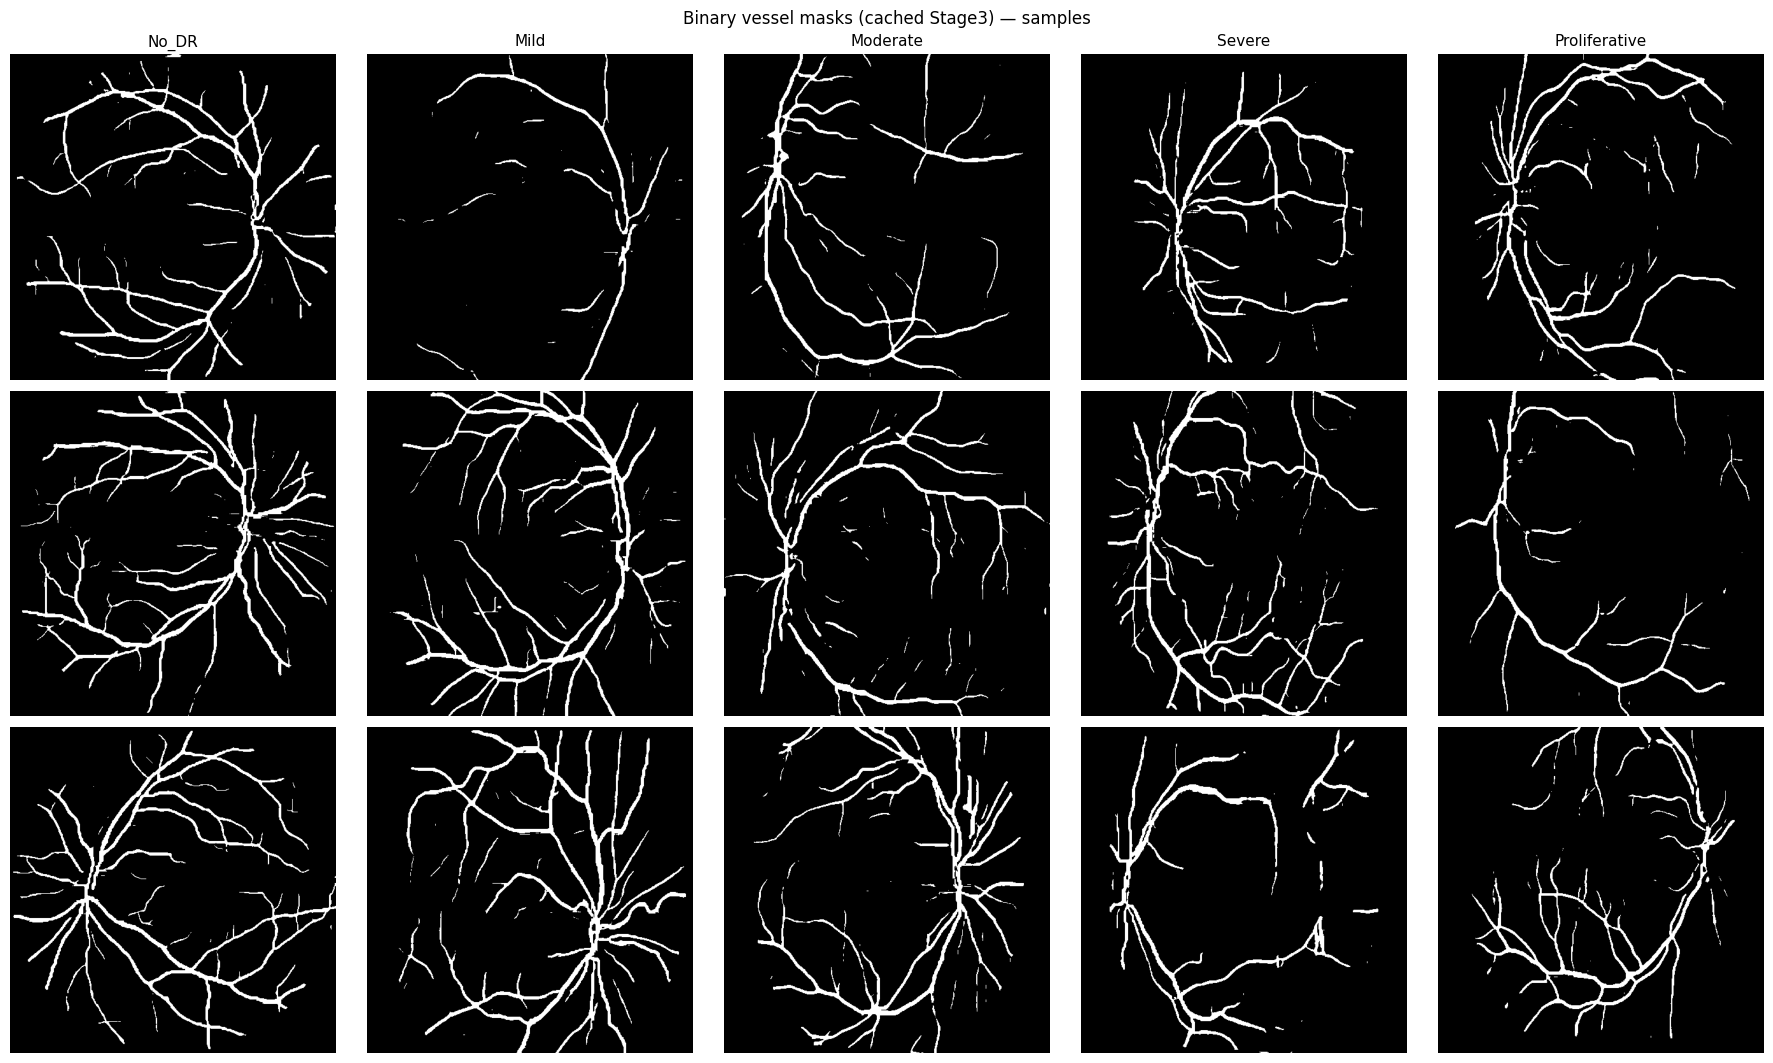

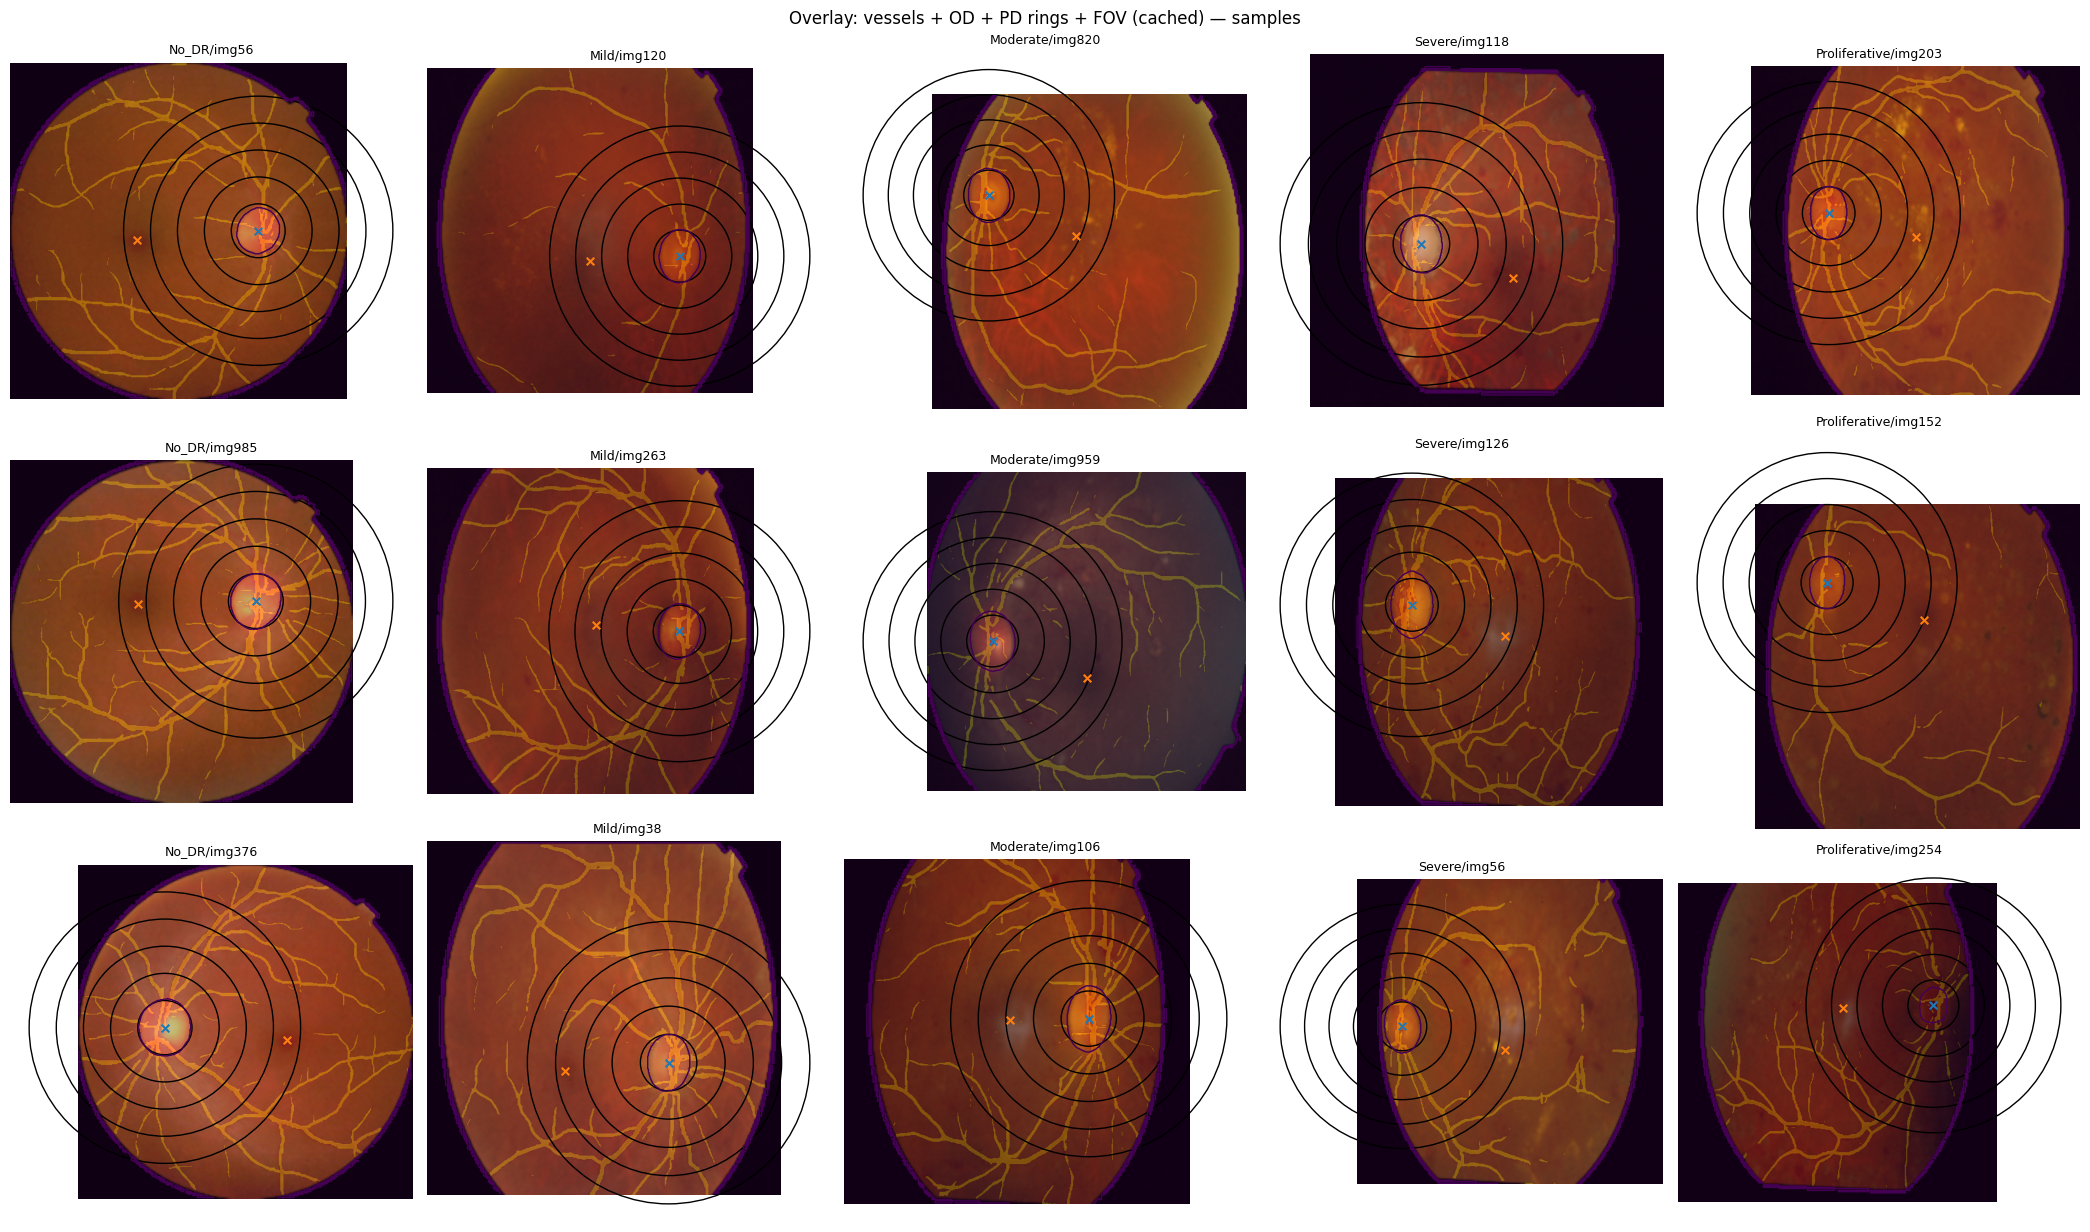

In [8]:
def safe_id(image_id: str) -> str:
    return image_id.replace("/", "__").replace("\\", "__")

def load_rgb_iso(image_id):
    return np.load(STAGE1_ROOT / safe_id(image_id) / "rgb_iso.npy")

def load_fov(image_id):
    p = STAGE1_ROOT / safe_id(image_id) / "fov_1hw.npy"
    return (np.load(p)[0] > 0.5) if p.exists() else None

def load_disc_mask(image_id):
    p = STAGE2_ROOT / safe_id(image_id) / "disc_mask.npy"
    return (np.load(p) > 0) if p.exists() else None

def load_od_json(image_id):
    return json.loads((STAGE2_ROOT / safe_id(image_id) / "od.json").read_text())

def load_fovea_center(image_id):
    p = STAGE2_ROOT / safe_id(image_id) / "fovea.json"
    if not p.exists():
        return None
    return json.loads(p.read_text()).get("fovea_center_yx", None)

def load_prob(image_id):
    return np.load(STAGE3_ROOT / safe_id(image_id) / "prob_map.npy").astype(np.float32)

def pred_mask(image_id, thr=0.5):
    prob = load_prob(image_id)
    m = (prob >= thr)
    f = load_fov(image_id)
    if f is not None:
        m = m & f
    return m

def draw_overlay_cached(ax, image_id, thr=0.5, ring_bounds=(0.5,1.0,1.5,2.0,2.5)):
    import matplotlib.patches as patches

    rgb = load_rgb_iso(image_id)
    fov = load_fov(image_id)
    disc = load_disc_mask(image_id)
    od = load_od_json(image_id)
    fv = load_fovea_center(image_id)
    m  = pred_mask(image_id, thr=thr)

    cy, cx = od["center_yx"]
    PD = float(od["PD_px"])

    ax.imshow(rgb)
    if fov is not None:
        ax.contour(fov.astype(float), levels=[0.5], linewidths=1.0)
    if disc is not None:
        ax.contour(disc.astype(float), levels=[0.5], linewidths=1.0)

    # vessel mask overlay
    ax.imshow(m.astype(float), alpha=0.25)

    # PD rings
    for rPD in ring_bounds:
        circ = patches.Circle((cx, cy), radius=rPD*PD, fill=False, linewidth=1.0)
        ax.add_patch(circ)

    ax.scatter([cx],[cy], s=30, marker="x")  # OD center
    if fv is not None:
        fy, fx = fv
        ax.scatter([fx],[fy], s=30, marker="x")  # fovea

    ax.set_title(image_id, fontsize=9)
    ax.axis("off")


# ---- pick samples per group ----
random.seed(7)
SAMPLES_PER_GROUP = 3
samples = {}
for g in GROUP_ORDER:
    ids = [o["image_id"] for o in outs_by_group[g]]
    random.shuffle(ids)
    samples[g] = ids[:SAMPLES_PER_GROUP]

# ---- binary mask grid ----
rows = SAMPLES_PER_GROUP
cols = len(GROUP_ORDER)
fig, axes = plt.subplots(rows, cols, figsize=(3.6*cols, 3.6*rows))
for c, g in enumerate(GROUP_ORDER):
    for r in range(rows):
        ax = axes[r, c]
        if r < len(samples[g]):
            mid = samples[g][r]
            ax.imshow(pred_mask(mid).astype(float), cmap="gray", vmin=0, vmax=1)
            if r == 0:
                ax.set_title(g, fontsize=11)
        ax.axis("off")
plt.suptitle("Binary vessel masks (cached Stage3) — samples", y=0.98)
plt.tight_layout()
plt.show()


# ---- overlay grid ----
fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 4.2*rows))
for c, g in enumerate(GROUP_ORDER):
    for r in range(rows):
        ax = axes[r, c]
        if r < len(samples[g]):
            draw_overlay_cached(ax, samples[g][r])
        else:
            ax.axis("off")
plt.suptitle("Overlay: vessels + OD + PD rings + FOV (cached) — samples", y=0.98)
plt.tight_layout()
plt.show()
